In [26]:
import duckdb
import numpy as np
import pandas as pd
import igraph as ig

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
plt.style.use("seaborn-v0_8")


In [27]:
graph_end_date = '2024-08-31'
block_window_start = '2024-09-01'
block_window_end   = '2024-09-30'

behavior_window_len = 30
min_blocks = 3


In [28]:
con = duckdb.connect()


In [29]:
con.execute(f"""
CREATE OR REPLACE TEMP TABLE eligible_users AS
SELECT did_id
FROM read_parquet('blocks.parquet')
WHERE created_date BETWEEN DATE '{block_window_start}' - INTERVAL 1 MONTH
                       AND DATE '{block_window_start}' - INTERVAL 1 DAY
GROUP BY did_id
HAVING COUNT(*) >= {min_blocks}
""")


In [30]:
labels = con.execute(f"""
SELECT
    e.did_id,
    COALESCE(b.cnt, 0) AS future_blocks
FROM eligible_users e
LEFT JOIN (
    SELECT did_id, COUNT(*) AS cnt
    FROM read_parquet('blocks.parquet')
    WHERE created_date BETWEEN DATE '{block_window_start}'
                          AND DATE '{block_window_end}'
    GROUP BY did_id
) b
ON e.did_id = b.did_id
""").fetchdf()


In [31]:
def block_class(x):
    if x <= 5:
        return 0   # low
    elif x <= 15:
        return 1   # medium
    else:
        return 2   # high

labels["block_class"] = labels["future_blocks"].apply(block_class)
labels["block_class"].value_counts(normalize=True)


block_class
2    0.372039
0    0.348870
1    0.279091
Name: proportion, dtype: float64

In [32]:
g = ig.Graph.Read_Pickle("frozen_graph_copy.pkl")
print(g.summary())


IGRAPH DN-- 34786 3687734 -- 
+ attr: name (v)


In [33]:
g.vs["out_degree"] = g.outdegree()
g.vs["in_degree"]  = g.indegree()
g.vs["pagerank"]   = g.pagerank()
g.vs["core"]       = g.coreness()

g_und = g.as_undirected()
g.vs["clustering"] = g_und.transitivity_local_undirected(mode="zero")

avg_deg = []
for v in g_und.vs:
    neigh = v.neighbors()
    avg_deg.append(np.mean([n.degree() for n in neigh]) if neigh else 0)

g.vs["avg_neighbor_degree"] = avg_deg


In [34]:
communities = g_und.community_leiden(
    objective_function="modularity",
    resolution=1.0
)

g.vs["community"] = communities.membership
print(f"Number of communities: {len(set(communities.membership))}")


Number of communities: 86


In [35]:
node_df = pd.DataFrame({
    "did_id": g.vs["name"],
    "community": g.vs["community"],
    "out_degree": g.vs["out_degree"],
    "in_degree": g.vs["in_degree"],
    "pagerank": g.vs["pagerank"],
    "core": g.vs["core"],
    "clustering": g.vs["clustering"],
    "avg_neighbor_degree": g.vs["avg_neighbor_degree"]
})


In [36]:
community_stats = (
    node_df
    .groupby("community")
    .agg(
        community_size=("did_id", "count"),
        mean_out_degree=("out_degree", "mean"),
        median_out_degree=("out_degree", "median"),
        frac_high_outdegree=("out_degree",
                             lambda x: (x > np.percentile(x, 66)).mean())
    )
    .reset_index()
)

node_df = node_df.merge(
    community_stats,
    on="community",
    how="left"
)


In [37]:
behavior_df = con.execute(f"""
SELECT
    did_id,
    COUNT(*) FILTER (WHERE event = 'post')   AS post_count,
    COUNT(*) FILTER (WHERE event = 'reply')  AS reply_count,
    COUNT(*) FILTER (WHERE event = 'like')   AS like_count,
    COUNT(*) FILTER (WHERE event = 'repost') AS repost_count
FROM (
    SELECT did_id, 'post' AS event
    FROM read_parquet('posts.parquet')
    WHERE created_date <= DATE '{graph_end_date}'

    UNION ALL
    SELECT did_id, 'reply'
    FROM read_parquet('posts.parquet')
    WHERE reply_parent_did_id IS NOT NULL
      AND created_date <= DATE '{graph_end_date}'

    UNION ALL
    SELECT did_id, 'like'
    FROM read_parquet('likes.parquet')
    WHERE created_date <= DATE '{graph_end_date}'

    UNION ALL
    SELECT did_id, 'repost'
    FROM read_parquet('reposts.parquet')
    WHERE created_date <= DATE '{graph_end_date}'
)
GROUP BY did_id
""").fetchdf()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [38]:
df = (
    node_df
    .merge(behavior_df, on="did_id", how="left")
    .merge(labels, on="did_id", how="inner")
)

df.fillna(0, inplace=True)
df["block_class"].value_counts(normalize=True)


block_class
2    0.374662
0    0.344161
1    0.281176
Name: proportion, dtype: float64

In [39]:
df["posts_per_day"]   = df["post_count"] / behavior_window_len
df["replies_per_day"] = df["reply_count"] / behavior_window_len

df["reply_ratio"]  = df["reply_count"]  / (df["post_count"] + 5)
df["like_ratio"]   = df["like_count"]   / (df["post_count"] + 5)
df["repost_ratio"] = df["repost_count"] / (df["post_count"] + 5)

df["in_out_ratio"] = df["in_degree"] / (df["out_degree"] + 1)


In [40]:
GRAPH_FEATURES = [
    "out_degree", "pagerank", "clustering", "avg_neighbor_degree"
]

COMMUNITY_FEATURES = [
    "community_size", "mean_out_degree",
    "median_out_degree", "frac_high_outdegree"
]

BEHAVIOR_FEATURES = [
    "posts_per_day", "replies_per_day",
    "reply_ratio", "like_ratio", "repost_ratio",
    "in_out_ratio"
]

ALL_FEATURES = GRAPH_FEATURES + COMMUNITY_FEATURES + BEHAVIOR_FEATURES


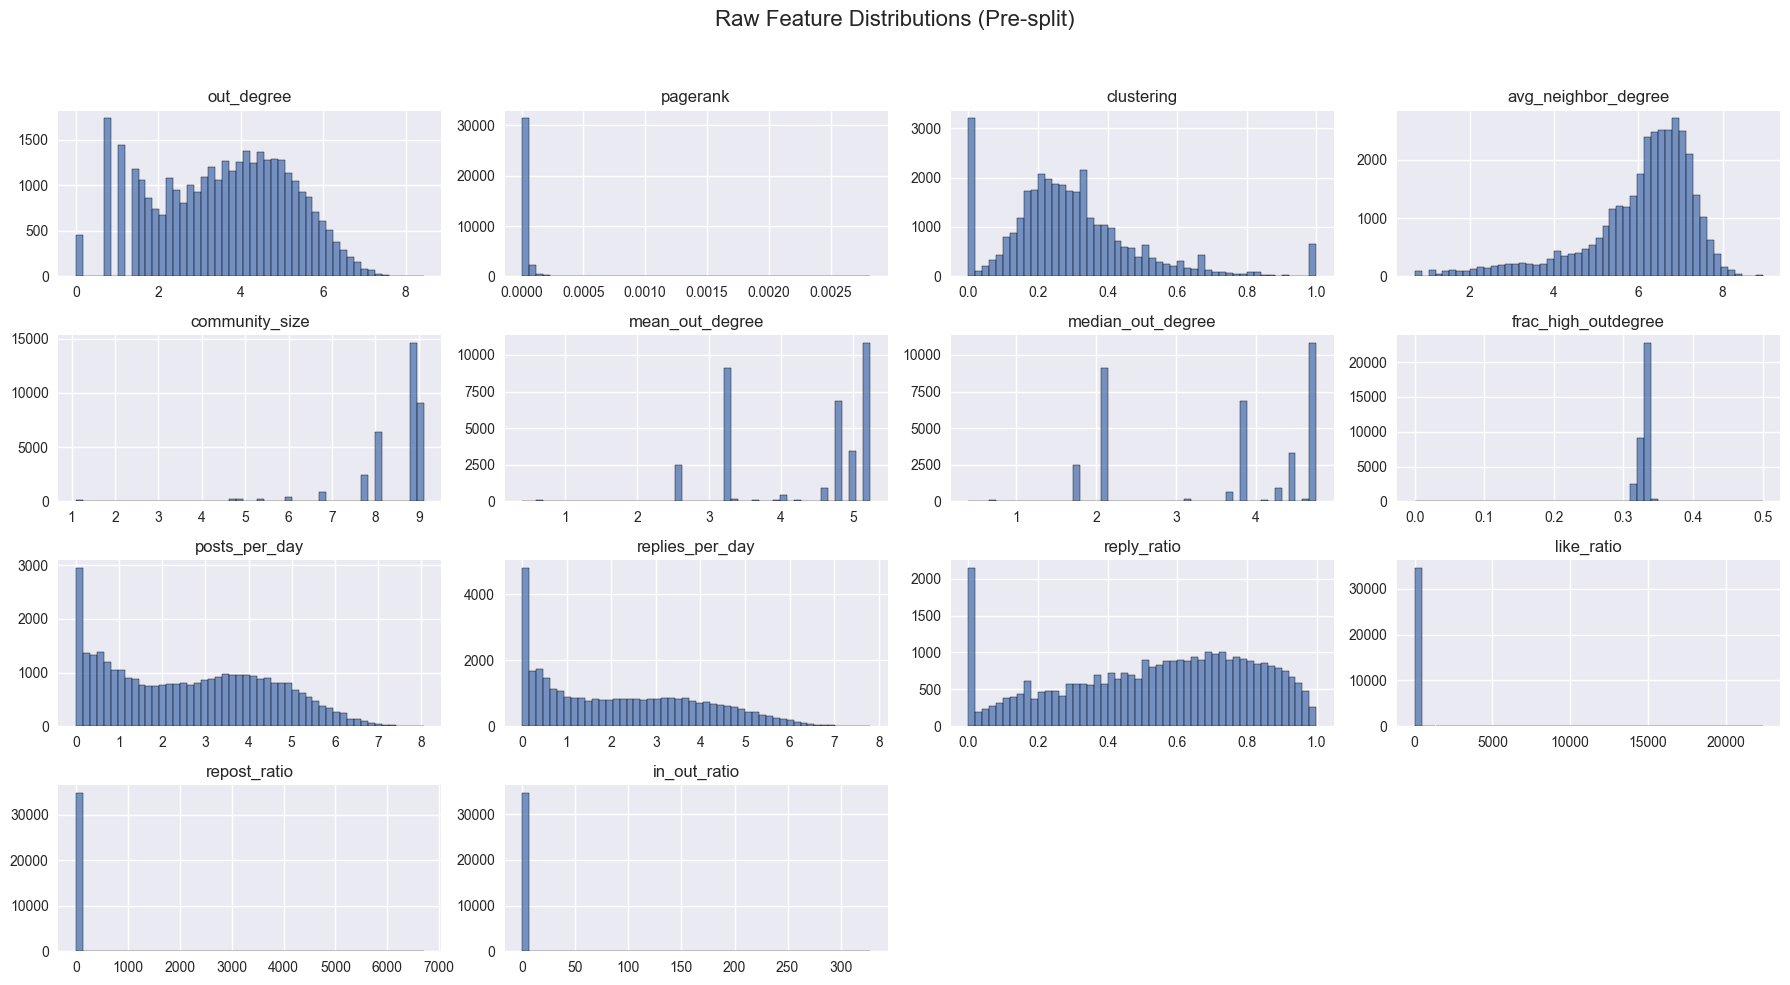

In [47]:
RAW_FEATURES = ALL_FEATURES.copy()

fig, axes = plt.subplots(
    int(np.ceil(len(RAW_FEATURES) / 4)), 4,
    figsize=(18, 10)
)
axes = axes.flatten()

for ax, col in zip(axes, RAW_FEATURES):
    sns.histplot(X[col], bins=50, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(RAW_FEATURES):]:
    ax.axis("off")

plt.suptitle("Raw Feature Distributions (Pre-split)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [41]:
X = df[ALL_FEATURES].copy()
y = df["block_class"]

LOG_COLS = [
    "out_degree", "avg_neighbor_degree",
    "community_size", "mean_out_degree", "median_out_degree",
    "posts_per_day", "replies_per_day"
]

for col in LOG_COLS:
    X[col] = np.log1p(X[col])


In [42]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


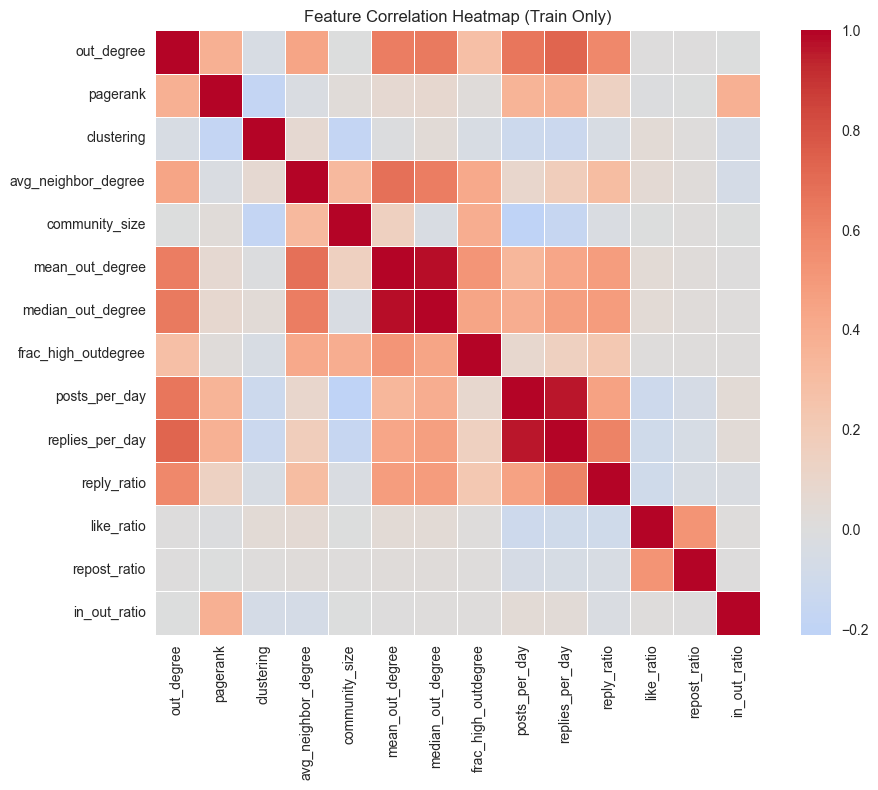

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    X_train.corr(),
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap (Train Only)")
plt.tight_layout()
plt.show()


In [50]:
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

print("Dropped due to high correlation:", to_drop)


Dropped due to high correlation: ['median_out_degree', 'replies_per_day']


In [51]:
X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)

SELECTED_FEATURES = X_train.columns.tolist()
print("Remaining features:", SELECTED_FEATURES)


Remaining features: ['out_degree', 'pagerank', 'clustering', 'avg_neighbor_degree', 'community_size', 'mean_out_degree', 'frac_high_outdegree', 'posts_per_day', 'reply_ratio', 'like_ratio', 'repost_ratio', 'in_out_ratio']


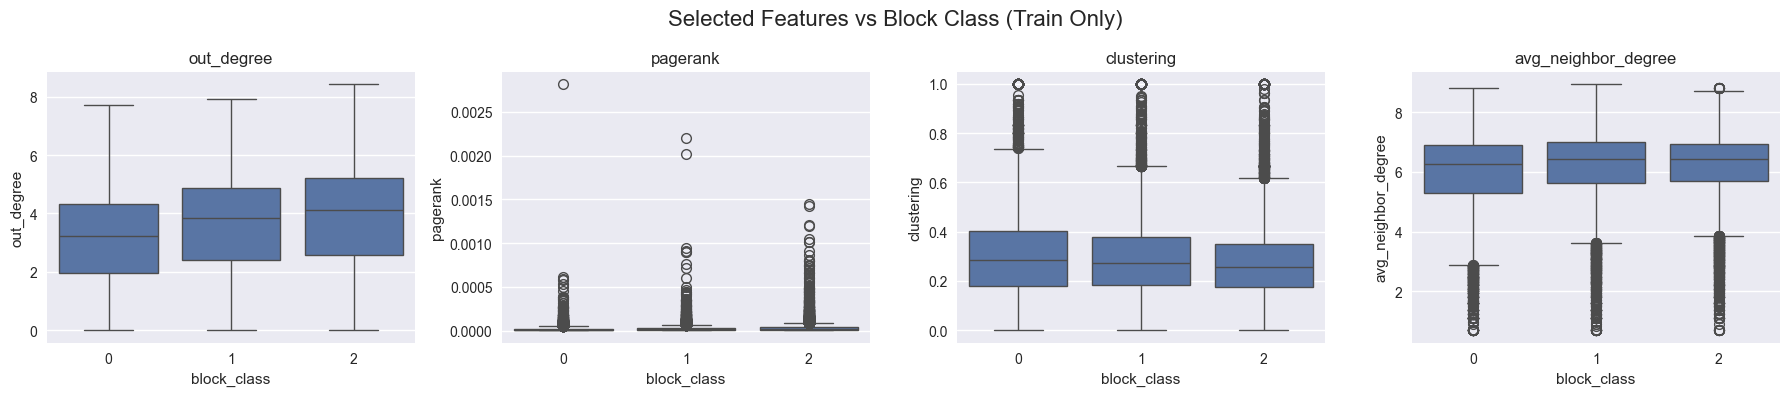

In [52]:
tmp = X_train.copy()
tmp["block_class"] = y_train.values

FEATURES_TO_CHECK = SELECTED_FEATURES[:4]  # pick a few

fig, axes = plt.subplots(1, len(FEATURES_TO_CHECK), figsize=(18, 4))

for ax, col in zip(axes, FEATURES_TO_CHECK):
    sns.boxplot(x="block_class", y=col, data=tmp, ax=ax)
    ax.set_title(col)

plt.suptitle("Selected Features vs Block Class (Train Only)", fontsize=16)
plt.tight_layout()
plt.show()


In [53]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=12,
    min_samples_leaf=30,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.52      0.47      0.49      2395
           1       0.35      0.30      0.32      1956
           2       0.51      0.61      0.55      2607

    accuracy                           0.47      6958
   macro avg       0.46      0.46      0.46      6958
weighted avg       0.47      0.47      0.47      6958



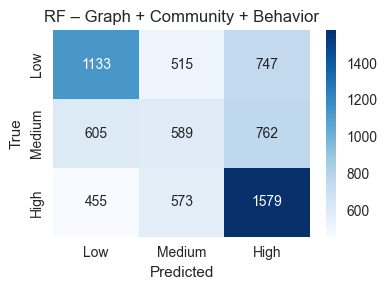

In [54]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)
plt.title("RF – Graph + Community + Behavior")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


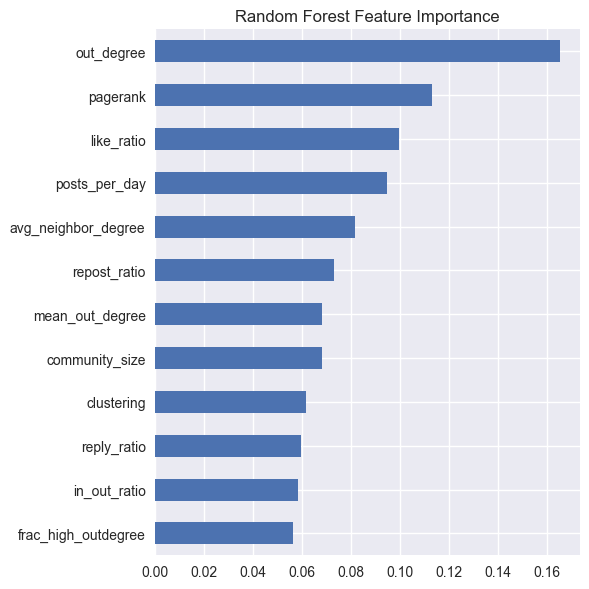

In [55]:
imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6, 6))
imp.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [56]:
def metrics(y_true, y_pred):
    return {
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Recall High": recall_score(y_true, y_pred, average=None)[2],
        "Precision High": precision_score(y_true, y_pred, average=None)[2],
        "Ordinal Error": np.mean(np.abs(y_true - y_pred))
    }

comparison = pd.DataFrame.from_dict({
    "Graph + Community + Behavior": metrics(y_val, y_pred)
}, orient="index")

comparison


,Macro F1,Recall High,Precision High,Ordinal Error
Graph + Community + Behavior,0.457556,0.605677,0.511334,0.698333


In [57]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict


{np.int64(0): np.float64(0.9685705335700114),
 np.int64(1): np.float64(1.1854313099041534),
 np.int64(2): np.float64(0.8896988298484558)}

In [60]:
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(
    objective="multiclassova",
    num_class=3,
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)


[LightGBM] [Info] Number of positive: 9577, number of negative: 18251
[LightGBM] [Info] Number of positive: 7825, number of negative: 20003
[LightGBM] [Info] Number of positive: 10426, number of negative: 17402
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2368
[LightGBM] [Info] Number of data points in the train set: 27828, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.03
,n_estimators,800
,subsample_for_bin,200000
,objective,'multiclassova'
,class_weight,"{np.int64(0): np.float64(0.9685705335700114), np.int64(1): np.float64(1.1854313099041534), np.int64(2): np.float64(0.8896988298484558)}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,40


In [61]:
y_pred_lgbm = lgbm.predict(X_val)

print(classification_report(y_val, y_pred_lgbm))


              precision    recall  f1-score   support

           0       0.52      0.48      0.50      2395
           1       0.35      0.30      0.32      1956
           2       0.51      0.60      0.55      2607

    accuracy                           0.48      6958
   macro avg       0.46      0.46      0.46      6958
weighted avg       0.47      0.48      0.47      6958



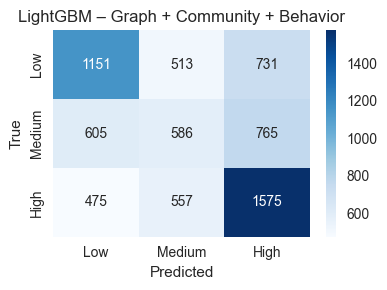

In [62]:
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Low", "Medium", "High"],
        yticklabels=["Low", "Medium", "High"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_confusion(
    y_val,
    y_pred_lgbm,
    "LightGBM – Graph + Community + Behavior"
)


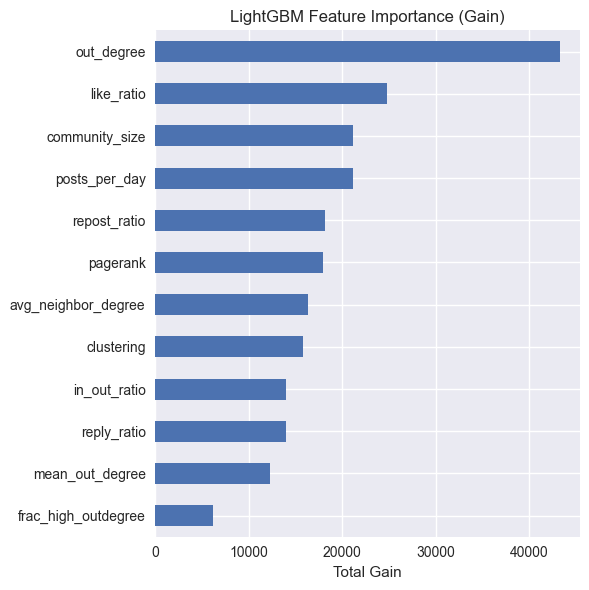

In [63]:
lgb_imp = pd.Series(
    lgbm.booster_.feature_importance(importance_type="gain"),
    index=X_train.columns
).sort_values()

plt.figure(figsize=(6, 6))
lgb_imp.plot(kind="barh")
plt.title("LightGBM Feature Importance (Gain)")
plt.xlabel("Total Gain")
plt.tight_layout()
plt.show()


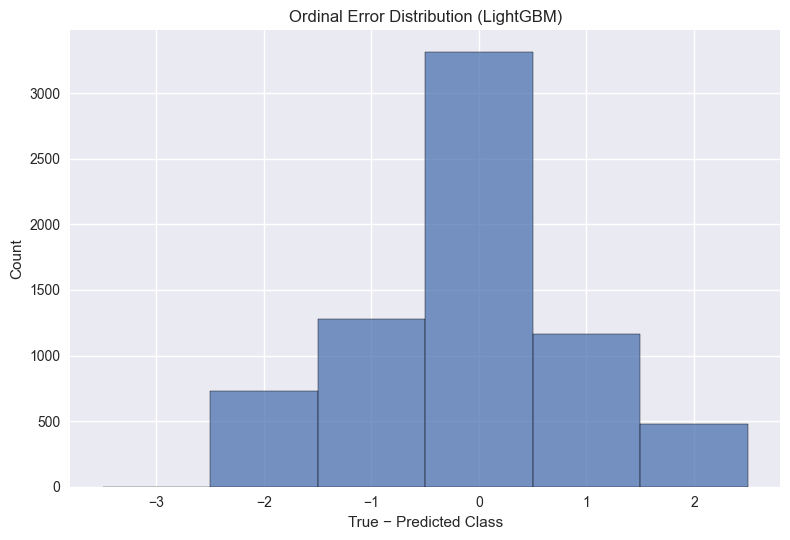

Mean absolute ordinal error: 0.6973268180511641


In [64]:
errors = y_val.values - y_pred_lgbm
sns.histplot(errors, bins=np.arange(-3, 4) - 0.5)
plt.xlabel("True − Predicted Class")
plt.title("Ordinal Error Distribution (LightGBM)")
plt.tight_layout()
plt.show()

print("Mean absolute ordinal error:",
      np.mean(np.abs(errors)))


In [65]:
def metrics(y_true, y_pred):
    return {
        "Macro F1": f1_score(y_true, y_pred, average="macro"),
        "Recall High": recall_score(y_true, y_pred, average=None)[2],
        "Precision High": precision_score(y_true, y_pred, average=None)[2],
        "Ordinal Error": np.mean(np.abs(y_true - y_pred))
    }

comparison = pd.DataFrame.from_dict({
    "Random Forest": metrics(y_val, y_pred),
    "LightGBM": metrics(y_val, y_pred_lgbm)
}, orient="index")

comparison


,Macro F1,Recall High,Precision High,Ordinal Error
Random Forest,0.457556,0.605677,0.511334,0.698333
LightGBM,0.458956,0.604143,0.512862,0.697327
